**Welcome to the pyLIMA tutorial on robust loss!**

In this tutorial we look at the implemented loss functions (objective functions) that can be used when fitting.

There are 3 loss functions in pyLIMA: 'chi2', 'likelihood' and 'soft_l1'.
Custom loss functions can be implemented.

While 'likelihood' can not be used with gradient-like methods (such as LM, TRF) 'chi2' and 'soft_l1' can be used with all fitting algorithms.

The difference between 'chi2' and 'soft_l1' is that 'soft_l1' is a robust loss.
They are defined as: 

$$ \text{chi2} = \sqrt{\sum \frac{ \text{res}^2 } { \text{errors}^2 } }$$

$$ \text{soft\_l1} = 2 \cdot \left(\sqrt{\sum \left(1 + \frac{ \text{res}^2 } { \text{errors}^2 } \right) } - 1 \right) $$

'soft_l1' can be viewed as a L2-loss for residuals close to 0 but as an L1-loss for larger residuals. This makes it less sensitive to outliers (/more robust).


In [178]:
### First import the required libraries
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

from pyLIMA.fits import TRF_fit
from pyLIMA.models import FSPL_model
from pyLIMA.outputs import pyLIMA_plots

from pyLIMA import event
from pyLIMA import telescopes

In [179]:
### Create a new EVENT object and give it a name.
your_event = event.Event()
your_event.name = 'My event name'

The datasets from example 1 are also used in this example. 

But here we add 3 additional datapoints to each dataset to simulate outliers. 
In reality these could be from a binary lensing event, instrument malfunction or physics that are not part of the model.
These datapoints will throw off the fitting algorithm when we do not use a robust loss function.

In [180]:
### Load up the data.
data_1 = np.loadtxt('./data/Survey_1.dat')
outliers_1 = [[80.055, 13.86, 0.01], [80.060, 13.76, 0.01], [80.065, 13.82, 0.01]]
data_1 = np.append(data_1, outliers_1, axis=0)

telescope_1 = telescopes.Telescope(name = 'OGLE', 
                                   camera_filter = 'I',
                                   lightcurve = data_1.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

data_2 = np.loadtxt('./data/Followup_1.dat')
outliers_2 = [[80.055, 10.10, 0.01], [80.060, 10.00, 0.01], [80.065,  10.05, 0.01]]
data_2 = np.append(data_2, outliers_2, axis=0)
telescope_2 = telescopes.Telescope(name = 'LCO', 
                                   camera_filter = 'I',
                                   lightcurve = data_2.astype(float),
                                   lightcurve_names = ['time','mag','err_mag'],
                                   lightcurve_units = ['JD','mag','mag'])

In [181]:
### Append these two telescope data sets to your EVENT object.
your_event.telescopes.append(telescope_1)
your_event.telescopes.append(telescope_2)

### Define the survey telescope that you want to use to align all other data sets to.
your_event.find_survey('OGLE')

### Run a quick sanity check on your input.
your_event.check_event()

check_event  : Everything looks fine...


Here we use a **FSPL MODEL** which should ignore any outliers or structures that could point to binary lensing effects.

In [182]:
pspl = FSPL_model.FSPLmodel(your_event)
your_event.telescopes[0].ld_gamma = 0.5
your_event.telescopes[1].ld_gamma = 0.5

We fit this using a **TRF-FIT**. 

The **LOSS FUNCTION** / Objective Function is defined as **'CHI2'** which is the default for gradient-like methods.
It is **NOT** a **ROBUST LOSS**.

In [183]:
### Define the fit.
my_fit_chi2 = TRF_fit.TRFfit(pspl, loss_function='chi2')

# my_fit_chi2.fit_parameters
my_fit_chi2.loss_function

'chi2'

In [184]:
### Execute the fitting algorithm.
my_fit_chi2.fit()

Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [80.09170459757144, 0.010985475158641837, 9.098680017813138, 0.02197128174839425, 2733.4359428865923, 3178.820582140201, 80175.65182837272, 213500.49214330525]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.93344202256263)),
             ('u0', np.float64(0.007825666401128414)),
             ('tE', np.float64(10.113044486771424)),
             ('rho', np.float64(0.021942804716588753)),
             ('fsource_OGLE', np.float64(2916.8279768675734)),
             ('ftotal_OGLE', np.float64(3125.8702632831832)),
             ('fsource_LCO', np.float64(92038.25246887018)),
             ('ftotal_LCO', np.float64(144852.12651805877)),
             ('chi2', np.float64(5326.443376903211))])


We plot the best model together with the data.

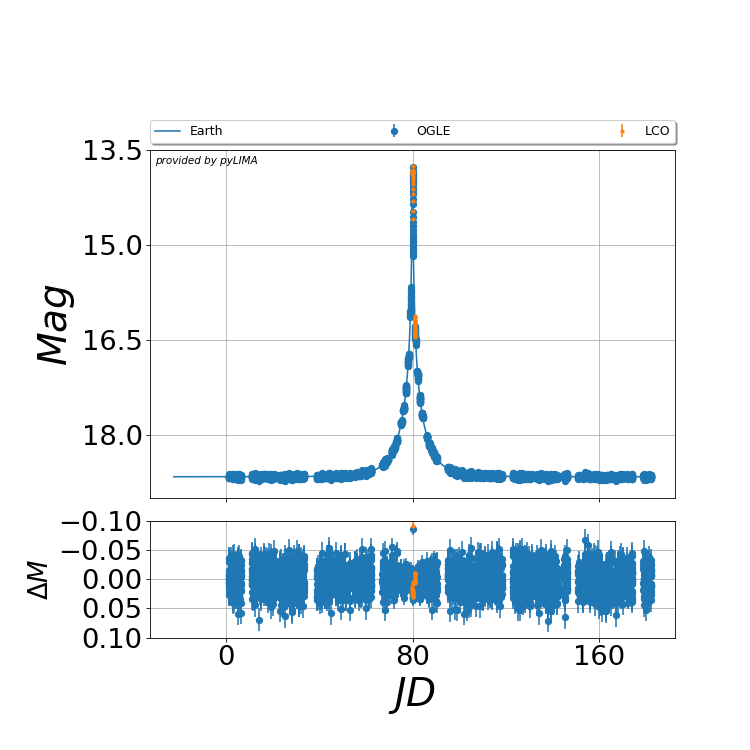

In [185]:
fig_chi2, _ = pyLIMA_plots.plot_lightcurves(pspl, my_fit_chi2.fit_results['best_model'])
plt.show()

We now fit the data again but with the **'SOFT_L1'** loss function. This is a **ROBUST LOSS**. 

In [186]:
### Define the fit.
my_fit_soft_l1 = TRF_fit.TRFfit(pspl, loss_function='soft_l1')

# my_fit_soft_l1.fit_parameters
my_fit_soft_l1.loss_function

'soft_l1'

In [187]:
### Execute the fitting algorithm.
my_fit_soft_l1.fit()

Selecting OGLE to estimate u0, tE and fs
initial_guess  : Initial parameters guess SUCCESS
Using guess:  [80.09170459757144, 0.010985475158641837, 9.098680017813138, 0.02197128174839425, 2733.4359428865923, 3178.820582140201, 80175.65182837272, 213500.49214330525]
Trust Region Reflective fit SUCCESS
best model:
OrderedDict([('t0', np.float64(79.93109200004932)),
             ('u0', np.float64(0.008142565869637327)),
             ('tE', np.float64(10.097779035856988)),
             ('rho', np.float64(0.02257389531697087)),
             ('fsource_OGLE', np.float64(2922.7655826394357)),
             ('ftotal_OGLE', np.float64(3126.1825698677617)),
             ('fsource_LCO', np.float64(92730.634086057)),
             ('ftotal_LCO', np.float64(141612.10224936853)),
             ('soft_l1', np.float64(2871.290788025437))])


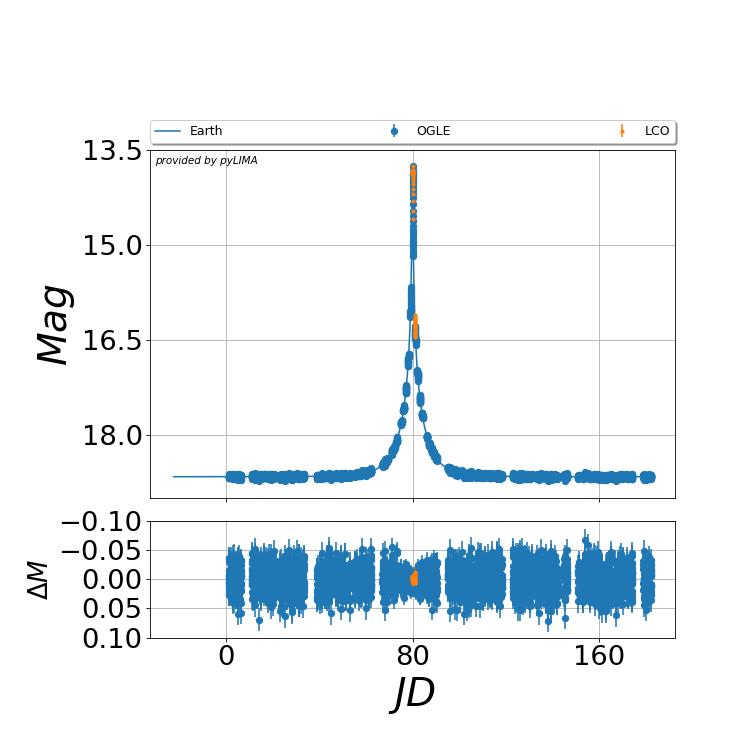

In [188]:
fig_soft_l1, _ = pyLIMA_plots.plot_lightcurves(pspl, my_fit_soft_l1.fit_results['best_model'])
plt.show()